# Single-Objective Plausible Inference Demo

This notebook demonstrates how to use the package in the **single-objective** setting, organized as a readable walkthrough. It implements the Plausible Inference framework; see the accompanying manuscript for the theory and notation used here.

This notebook has four parts:

1. **Create the unknown ground truth and general setup** — In the real world, we do *not* know the
   objective function; we only observe noisy simulation output at a finite **experimental set**
   of solutions. Here, we fabricate a ground-truth objective.
2. **Problem configuration** — The *acceptability* (what makes a solution acceptable), the
   *functional properties* (structural assumptions on the objective function), and the
   *confidence region* (built from the per-solution summary statistics).
3. **How to use the package** — Build the Pyomo model and screen every candidate solution in the
   solution space (in parallel or sequentially).
4. **Visualize the result** — Plot the plausibly acceptable solutions.

## 1. Create the unknown ground truth and general setup

In practice, the objective function $\theta$ is **unknown**: we can only run the simulation at a
finite **experimental set** $\mathsf{X} = \{\mathbf{x}_1, \ldots, \mathbf{x}_k\}$ of solutions,
observe noisy replications, and estimate a mean / variance for each solution.

For demonstration and validation, this notebook fixes a single **quadratic ground-truth
objective** over the decision vector $\mathbf{x} = (x_1, x_2)$:

$$ \theta(\mathbf{x}) = \tfrac12\, \mathbf{x}^\top Q\, \mathbf{x} + c^\top \mathbf{x} + b. $$

$Q$ is positive definite, so $\theta$ is convex. This justifies the `convexity`
functional property used later.

Plausible Inference does not consume the ground-truth objective
itself. Its inputs are an **experimental set** together with the **noisy observations** collected
on it (or their **summary statistics**). The steps
below produce those inputs:

1. Define the ground-truth objective `quad_f` (a stand-in for the unknown objective function, used only to
   generate the synthetic observations below).
2. Build a grid `feas_region` of candidate solutions over the solution-space box, used for the
   contour plot and for the later solution-space pixelization.
3. Sample a finite **experimental set** `exp_set`.
4. Run noisy replications at each solution in the experimental set to obtain the per-solution
   summary statistics `sample_mean` / `sample_var` / `sample_size`. These statistics (or
   confidence bounds) are the only data plausible inference requires.

In [18]:
import sys
import os
import time
import numpy as np
import pyomo.environ as pyo
from multiprocessing import Pool, cpu_count
import matplotlib.pyplot as plt

# add the project root to the python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# core model builder + batch screening helpers
from src.plausible_inference.model_construction import model_construction
from src.plausible_inference.execution_engine import ExecutionConfig, run_execution_engine

In [19]:
# ----------------------------
# 1) define the unknown ground-truth function f(x) = f(x1, x2)
#    f(x) = 0.5 * x^T Q x + c^T x + b,  x = (x1, x2)
#    (unknown in practice; used here only to generate data and to compare later)
# ----------------------------
Q = np.array([[2.0, 0.6],
              [0.6, 1.2]])  # positive definite -> f is convex
c = np.array([-1.0, 0.8])
b = 0.3

def quad_f(x: np.ndarray) -> float:
    """value of the (unknown) ground-truth quadratic at x = (x1, x2)"""
    x = np.asarray(x, dtype=float).reshape(2,)
    return 0.5 * x @ Q @ x + c @ x + b


# ----------------------------
# 2) build a grid of candidate solutions over the solution-space box
#    (used for the contour plot and the later solution-space pixelization)
# ----------------------------
x1_min, x1_max = -2.0, 2.0
x2_min, x2_max = -1.5, 1.5
grid_n1, grid_n2 = 80, 60  # grid resolution

x1s = np.linspace(x1_min, x1_max, grid_n1)
x2s = np.linspace(x2_min, x2_max, grid_n2)
X1, X2 = np.meshgrid(x1s, x2s, indexing="xy")
feas_region = np.column_stack([X1.ravel(), X2.ravel()])  # (N, 2)


# ----------------------------
# 3) sample experimental solutions from the feasible region (the solutions we simulated)
# ----------------------------
rng = np.random.default_rng(123)

num_exp_solutions = 20
exp_indices = rng.choice(feas_region.shape[0], size=num_exp_solutions, replace=False)
exp_set = feas_region[exp_indices]  # (num_exp_solutions, 2)


# ----------------------------
# 4) generate noisy samples at each experimental solution and record the statistics
#    (heterogeneous sample sizes allowed; here each solution is repeated 80-100 times)
# ----------------------------
sample_size = rng.integers(low=80, high=100, size=num_exp_solutions)

sample_mean = np.empty(num_exp_solutions, dtype=float)
sample_var  = np.empty(num_exp_solutions, dtype=float)
raw_samples = []

for i, x in enumerate(exp_set):
    n = int(sample_size[i])
    true_val = quad_f(x)              # unknown in practice
    noise = rng.standard_normal(n)    # N(0,1) noise
    y = true_val + noise

    raw_samples.append(y)
    sample_mean[i] = y.mean()
    if n >= 2:
        sample_var[i]  = y.var(ddof=1)
    else:
        raise ValueError("sample size must be at least 2")

print("✅ Test data generation completed!")
print(f"  exp_set shape: {exp_set.shape}")
print(f"  feas_region shape: {feas_region.shape}")
print(f"  sample_mean shape: {sample_mean.shape}")

✅ Test data generation completed!
  exp_set shape: (20, 2)
  feas_region shape: (4800, 2)
  sample_mean shape: (20,)


### Visualization of the ground truth

Plot the unknown ground-truth quadratic over the feasible region and mark the
**experimental solutions** `exp_set` we simulated. Note: this plot uses `quad_f`,
which is invisible in practice — it is shown here only for intuition.

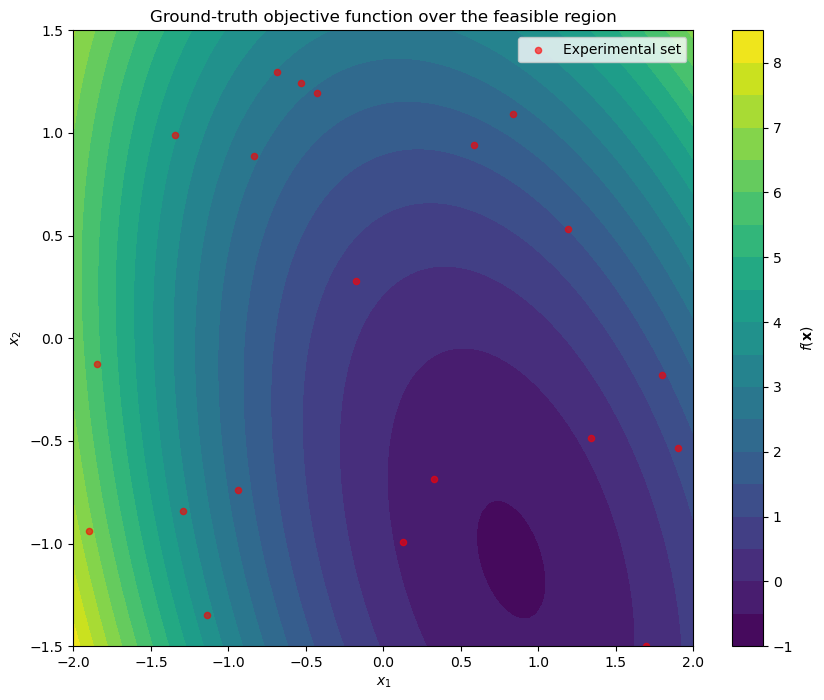

In [20]:
# Calculate function values on the grid and reshape for plotting
F = np.array([quad_f(x) for x in feas_region]).reshape(grid_n2, grid_n1)

plt.figure(figsize=(10, 8))
plt.contourf(X1, X2, F, levels=20)
plt.colorbar(label=r"$f(\mathbf{x})$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Ground-truth objective function over the feasible region")
plt.scatter(exp_set[:, 0], exp_set[:, 1], c='red', s=20, alpha=0.6, label='Experimental set')
plt.legend()
plt.show()

## 2. Problem configuration

The core question of plausible inference is: **"Given the data and the structural assumptions,
is a candidate solution $\mathbf{x}_0$ _plausibly acceptable_?"** Answering it requires
configuring three elements of the PI framework: the acceptability, the functional properties,
and the confidence region.

### 2.1 Acceptability (what counts as "acceptable")

Acceptability states what makes a solution worth keeping. PI supports a wide range of
acceptability definitions; the table lists the single-objective options demonstrated here and
the parameter (if any) each one needs.

| Name | Meaning | Parameters |
|---|---|---|
| `single-objective-optimality` | the candidate could be the minimizer of the objective | none |
| `delta-optimality` | the candidate is within `delta` of the best solution | `delta` (>= 0) |
| `feasibility` | the candidate's objective can meet a target `threshold` | `threshold` |
| `within-threshold` | the candidate's objective can lie within `delta` of `threshold` | `threshold`, `delta` (>= 0) |

The next cell lists every option; keep the one you want and comment out the rest.

### 2.2 Functional properties (structural assumptions on the objective function)

Each objective gets a set of properties chosen from: `convexity`, `concavity`,
`Lipschitz_continuity`, `directional_Lipschitz_continuity`. The cell below lists every option (and combined
examples); keep the one you want.

### 2.3 Confidence region

The confidence region describes the uncertainty of the objectives at the experimental set. The
`discrepancy_type` parameter controls how this region is constructed from the observed summary
statistics:

- a discrepancy with a cutoff at `confidence_level`: `norm_1` ($\ell_1$), `norm_2` ($\ell_2$),
  `norm_infinite` ($\ell_\infty$), or `CRN` ($\ell_{\mathrm{CRN}}$); or
- `confidence_region`: a **customized hyperrectangle** — supply your own precomputed
  `upper_confidence_bounds` / `lower_confidence_bounds` directly.

The cell below lists every option; keep the one you want.

In [21]:
# ---- 2.1 Acceptability: what makes a candidate solution x0 "acceptable" ----
# Constraints act on the candidate objective value m[0, 1] (minimization).
# Keep ONE block; comment out the rest.

# (a) single-objective optimality: x0 could be the minimizer
acceptability = 'single-objective-optimality'
acceptability_parameters = None

# (b) delta-optimality: within `delta` of the best
# acceptability = 'delta-optimality'
# acceptability_parameters = {'delta': 3.0}

# (c) feasibility: objective can be at or below a target value
# acceptability = 'feasibility'
# acceptability_parameters = {'threshold': -1.0}

# (d) within-threshold: objective can lie in [threshold - delta, threshold + delta]
# acceptability = 'within-threshold'
# acceptability_parameters = {'threshold': 8.0, 'delta': 1.0}

print(f"acceptability            : {acceptability}")
print(f"acceptability_parameters : {acceptability_parameters}")

acceptability            : single-objective-optimality
acceptability_parameters : None


In [22]:
# ---- 2.2 Functional properties: structural assumptions on the objective ----
# One property set + one parameter dict for the (single) objective.
# Keep ONE block; comment out the rest.

# (a) convexity only (no extra parameters)
# functional_properties_obj1 = {'convexity'}
# functional_parameters_obj1 = {}

# (b) concavity only -- not applicable here since quad_f is convex, not concave
# functional_properties_obj1 = {'concavity'}
# functional_parameters_obj1 = {}

# (c) global Lipschitz continuity (single constant)
functional_properties_obj1 = {'Lipschitz_continuity'}
functional_parameters_obj1 = {'lip_CST': 6.3}

# (d) directional Lipschitz continuity: one Lipschitz constant per input dimension.
#     `lip_CST_vector` must be a list with the same length as the input dimension (here 2).
# functional_properties_obj1 = {'directional_Lipschitz_continuity'}
# functional_parameters_obj1 = {'lip_CST_vector': [5.9, 3.8]}

# (e) combine convexity with a global Lipschitz bound
# functional_properties_obj1 = {'convexity', 'Lipschitz_continuity'}
# functional_parameters_obj1 = {'lip_CST': 6.3}

# (f) combine convexity with directional Lipschitz continuity
# functional_properties_obj1 = {'convexity', 'directional_Lipschitz_continuity'}
# functional_parameters_obj1 = {'lip_CST_vector': [5.9, 3.8]}

# single objective -> a one-element list each
functional_properties_list = [functional_properties_obj1]
functional_properties_parameters = [functional_parameters_obj1]

num_of_objectives = int(1)
inference_type = 'screening'

print(f"num_of_objectives : {num_of_objectives}")
print(f"inference_type    : {inference_type}")
print(f"functional props  : {functional_properties_list}")
print(f"functional params : {functional_properties_parameters}")
print(f"k (exp solutions) : {exp_set.shape[0]}")
print(f"s (dimension)     : {exp_set.shape[1]}")

num_of_objectives : 1
inference_type    : screening
functional props  : [{'Lipschitz_continuity'}]
functional params : [{'lip_CST': 6.3}]
k (exp solutions) : 20
s (dimension)     : 2


In [23]:
# ---- 2.3 Confidence region: how each experimental m[i, 1] is bounded ----
# Keep ONE block. Each fills `confidence_kwargs`, unpacked into model_construction(...).

confidence_level = 0.95
sample_mean_2d = sample_mean.reshape(-1, 1)   # (k, 1), single objective

# (a) CRN (l_CRN discrepancy): designed for Common Random Numbers experiments, where the
#     same random seed is reused across solutions so that simulation noise is correlated.
#     `sample_var` must be a (k, k) sample covariance matrix estimated from the paired
#     replications. A scalar sample size (the same n for all solutions) is also required.
#
#     NOTE: the demo below constructs a *diagonal* covariance matrix from per-solution
#     variances, which implicitly assumes independence. If your experiment is truly
#     independent (no CRN), prefer option (b) or (c) instead; or provide the actual
#     full sample covariance matrix here:
#
# sample_cov = np.cov(raw_samples, rowvar=True)  # (k, k), requires equal sample sizes
# discrepancy_type = 'CRN'
# confidence_kwargs = dict(
# sample_mean=sample_mean_2d,
#     sample_var=np.diag(sample_var),                     # (k, k) diagonal — independence placeholder
#     sample_size=np.array([float(sample_size.min())]),  # (d,) = (1,)
#     confidence_level=confidence_level,
# )

# (b) norm-based discrepancy: 'norm_1' (l_1), 'norm_2' (l_2), 'norm_infinite' (l_inf)
# discrepancy_type = 'norm_infinite'
# confidence_kwargs = dict(
#     sample_mean=sample_mean_2d,
#     sample_var=sample_var.reshape(-1, 1),      # (k, 1)
#     sample_size=sample_size.reshape(-1, 1),    # (k, 1)
#     confidence_level=confidence_level,
# )

# (c) confidence_region: customized hyperrectangle -- supply your OWN bounds, shape (k, 1) each.
#     This lets you use any bespoke interval. Under the independence assumption, the exact
#     joint-coverage correction is Sidak: each per-solution interval uses level
#     (1 - alpha_i) where alpha_i = 1 - (1 - alpha)^(1/k).
#
from scipy.stats import t as t_dist
k = len(sample_mean)
alpha_i = 1.0 - (1.0 - (1.0 - confidence_level)) ** (1.0 / k)  # Sidak per-interval alpha
t_crit = t_dist.ppf(1.0 - alpha_i / 2, df=sample_size - 1)     # (k,)
half_width = t_crit * np.sqrt(sample_var / sample_size)         # (k,)
upper_confidence_bounds = sample_mean_2d + half_width.reshape(-1, 1)
lower_confidence_bounds = sample_mean_2d - half_width.reshape(-1, 1)
discrepancy_type = 'confidence_region'
confidence_kwargs = dict(
    upper_confidence_bounds=upper_confidence_bounds,
    lower_confidence_bounds=lower_confidence_bounds,
)

print(f"discrepancy_type : {discrepancy_type}")
print(f"confidence_kwargs keys : {sorted(confidence_kwargs)}")

discrepancy_type : confidence_region
confidence_kwargs keys : ['lower_confidence_bounds', 'upper_confidence_bounds']


## 3. How to use it (build the model & run screening)

1. **Build the complete model once** with `model_construction(...)`. The model encodes
   `exp_set`, the acceptability, the functional properties, and the confidence region
   (`**confidence_kwargs`) into a single Pyomo model.
2. **Run screening for every candidate solution in the feasible region**: decide whether
   each $\mathbf{x}_0$ could be acceptable. The solve cell offers two equivalent strategies in
   one place: **parallel** (the default) and **cold sequential** (commented out) both
   produce the same `all_results`.

In [24]:
print("\n📦 Creating the screening model...")
model_start = time.time()

M_model = model_construction(
    exp_set,
    num_of_objectives,
    inference_type,
    functional_properties_list,
    acceptability=acceptability,
    acceptability_parameters=acceptability_parameters,
    discrepancy_type=discrepancy_type,
    functional_properties_parameters=functional_properties_parameters,
    **confidence_kwargs,
)
# The plausible_inference package defaults to the open-source solver SCIP. You may use any
# solver supported by Pyomo (e.g. 'scip', 'gurobi', 'cplex'); make sure the chosen solver
# supports the optimization problems generated by plausible inference (LP / MILP / MIQP) and
# that Pyomo has the matching interface installed. This demo uses Gurobi.
solver = pyo.SolverFactory('gurobi')

print(f"✅ Model created in {time.time() - model_start:.4f} s")


📦 Creating the screening model...
✅ Model created in 0.0385 s


In [25]:
# ---- Run screening: pick a solve strategy (parallel is the default) ----

# Option A (default): parallel solve -- recommended for large feasible regions.
# The execution engine builds one task per candidate solution (model built once,
# reused) and maps over an internal Pool. It returns a uniform DataFrame.
print(f"🚀 Parallel screening of {len(feas_region)} candidate solutions...")
time_start = time.time()
all_results_df = run_execution_engine(
    ExecutionConfig(inference_type="screening", execution="parallel"),
    M_model,
    solver,
    feas_region,
)
print(f"✅ Done in {time.time() - time_start:.2f} s")

# Option B: cold sequential solve -- single process, simpler to debug, slower on
# large grids. Produces the same `all_results_df`. Uncomment to use INSTEAD of A.
# all_results_df = run_execution_engine(
#     ExecutionConfig(inference_type="screening"), M_model, solver, feas_region
# )

# Records view for downstream cells (idx / result / solve_status columns).
all_results = all_results_df.to_dict("records")

🚀 Parallel screening of 4800 candidate solutions...
✅ Done in 4.80 s


In [26]:
# ---- Screening statistics (works on all_results from either option) ----
feasible_results   = [r for r in all_results if r.get('result') == 'returned']
infeasible_results = [r for r in all_results if r.get('result') == 'screened_out']
failed_results     = [r for r in all_results if r.get('solve_status') == 'error']

print("Screening statistics:")
print(f"  Acceptable (returned) : {len(feasible_results)}")
print(f"  Screened-out          : {len(infeasible_results)}")
print(f"  Failed (errors)       : {len(failed_results)}")

Screening statistics:
  Acceptable (returned) : 2935
  Screened-out          : 1865
  Failed (errors)       : 0


## 4. Visualize the screening result

Color the candidate solutions in the solution space by their screening outcome:

- **Returned Solution** (light grey): solutions that are *plausibly acceptable* and kept;
- **Screened-Out Solution** (medium grey): solutions that are screened out;
- **Experimental Set** (black diamonds): the simulated solutions.

Screening every solution on the grid is the *discretization* approach, so the returned
solutions form an inner approximation of the confidence region for the acceptable set.

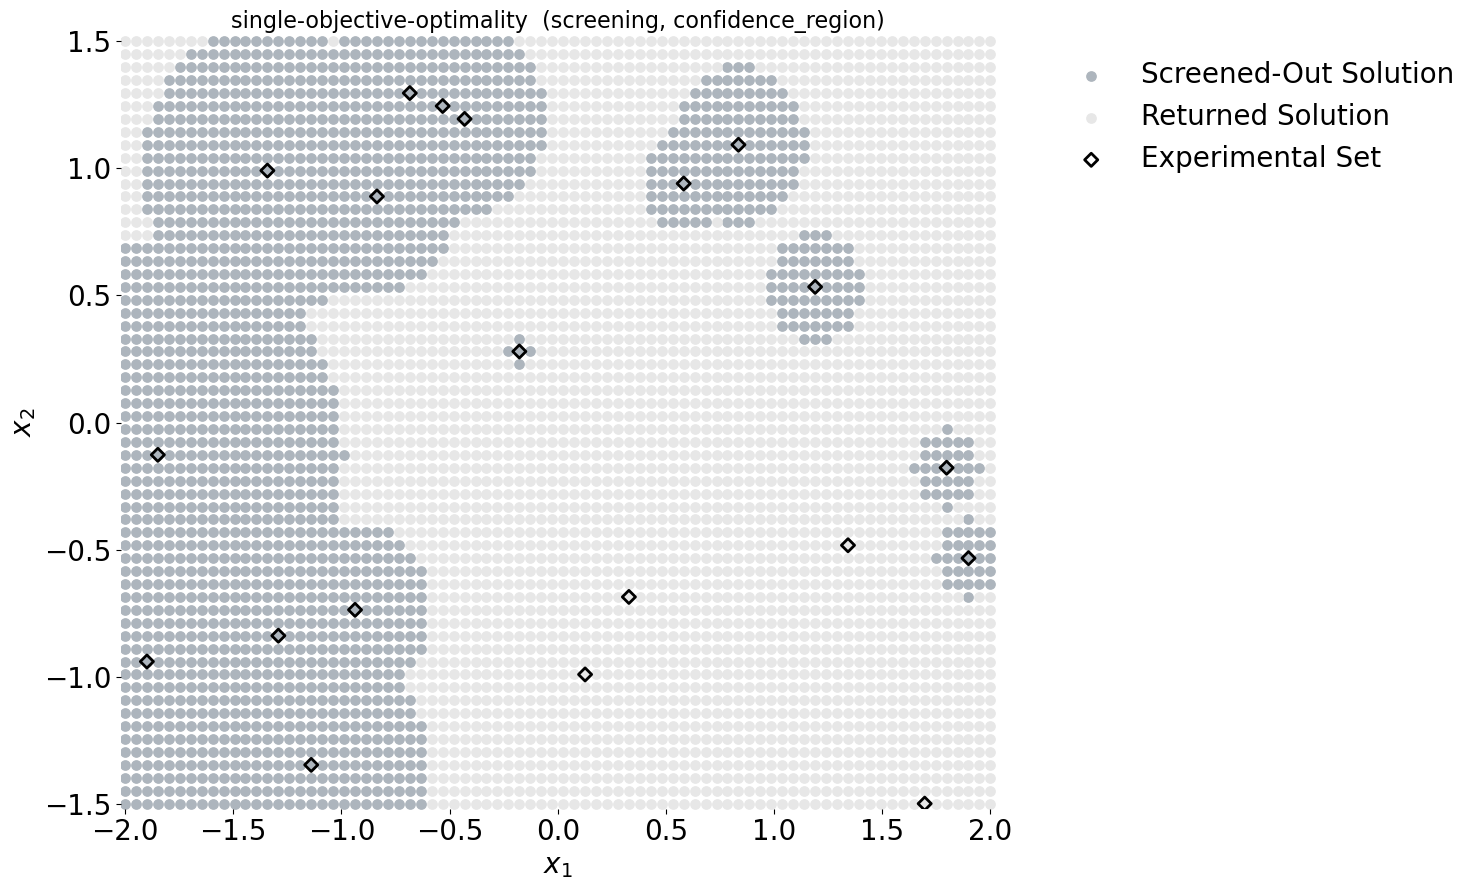

In [27]:
# Define colors matching the reference style
color_0 = '#e7e7e7'  # lightest grey - Returned Solution (feasible)
color_1 = '#adb5bd'  # median grey   - Screened-Out Solution (infeasible)
color_2 = 'black'    # black         - Experimental Set

# Create feasibility array aligned with feas_region
feasibility_array = np.zeros(len(feas_region), dtype=int)
for result in all_results:
    feasibility_array[result['idx']] = 1 if result.get('result') == 'returned' else 0

plt.figure(figsize=(15, 9))
scatter_size = 45

mask_infeasible = (feasibility_array == 0)
plt.scatter(feas_region[mask_infeasible, 0],
            feas_region[mask_infeasible, 1],
            c=color_1, s=scatter_size, label='Screened-Out Solution')

mask_feasible = (feasibility_array == 1)
plt.scatter(feas_region[mask_feasible, 0],
            feas_region[mask_feasible, 1],
            c=color_0, s=scatter_size, label='Returned Solution')

plt.scatter(exp_set[:, 0], exp_set[:, 1],
            s=scatter_size, color='none', edgecolors=color_2,
            label='Experimental Set', linewidths=2, marker='D')

ax = plt.gca()
ax.spines['left'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlim(x1_min - 0.02, x1_max + 0.02)
plt.ylim(x2_min - 0.02, x2_max + 0.02)
plt.xlabel(r'$x_1$', fontsize=20)
plt.ylabel(r'$x_2$', fontsize=20)
plt.title(f"{acceptability}  ({inference_type}, {discrepancy_type})", fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=20)
plt.legend(fontsize=20, frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 5. Solution-space (input) pixelization

Screening on the grid above tests one candidate solution at a time. **Input pixelization** asks
the same question about an entire *box* (pixel) of the solution space at once: a pixel is
*returned* if it contains at least one solution $\mathbf{x}_0$ that is plausibly acceptable. This approach partitions the solution space into cells, yielding
an **outer** approximation of the confidence region (vs. the inner approximation from
discretization).

We reuse the same acceptability, functional properties, and confidence region from Section 2;
only `inference_type` becomes `'input_pixelization'`. Each task is a pixel in the solution space, described by `[pixel_lb, pixel_ub]`.

In [28]:
from src.plausible_inference.execution_engine import ExecutionConfig, run_execution_engine

# Partition the decision-space box into a coarse grid of pixels (cells).
cells_n1, cells_n2 = 20, 15
edges_x1 = np.linspace(x1_min, x1_max, cells_n1 + 1)
edges_x2 = np.linspace(x2_min, x2_max, cells_n2 + 1)

pixel_lb_list, pixel_ub_list = [], []
for i in range(cells_n1):              # cell index = i * cells_n2 + j
    for j in range(cells_n2):
        pixel_lb_list.append([edges_x1[i],     edges_x2[j]])
        pixel_ub_list.append([edges_x1[i + 1], edges_x2[j + 1]])
pixel_lb = np.array(pixel_lb_list)     # (n_cells, 2)
pixel_ub = np.array(pixel_ub_list)     # (n_cells, 2)
n_cells = pixel_lb.shape[0]

# Reuse the Section-2 acceptability / functional properties / confidence region;
# only inference_type changes to 'input_pixelization'.
M_input = model_construction(
    exp_set,
    num_of_objectives,
    'input_pixelization',
    functional_properties_list,
    acceptability=acceptability,
    acceptability_parameters=acceptability_parameters,
    discrepancy_type=discrepancy_type,
    functional_properties_parameters=functional_properties_parameters,
    **confidence_kwargs,
)
solver = pyo.SolverFactory('scip')

print(f"🚀 Input pixelization: {n_cells} pixels...")
time_start = time.time()
input_results_df = run_execution_engine(
    ExecutionConfig(inference_type="input_pixelization", execution="parallel"),
    M_input,
    solver,
    (pixel_lb, pixel_ub),
)
input_results = input_results_df.to_dict("records")
print(f"✅ Done in {time.time() - time_start:.2f} s")
print(f"  returned pixels: {sum(r.get('result') == 'returned' for r in input_results)} / {n_cells}")

🚀 Input pixelization: 300 pixels...
✅ Done in 3.19 s
  returned pixels: 215 / 300


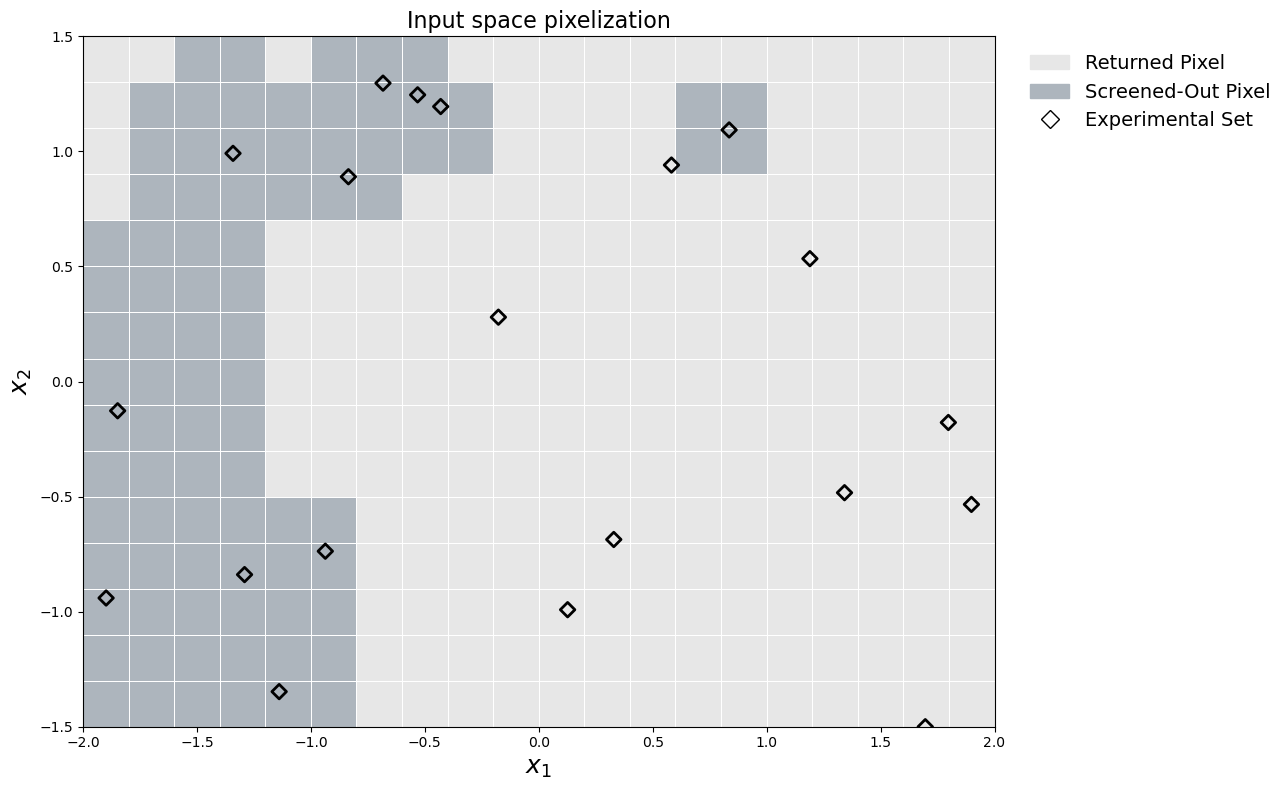

In [29]:
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# feasibility per cell -> grid (rows = x2, cols = x1)
feas_cell = np.zeros(n_cells, dtype=int)
for r in input_results:
    feas_cell[r['idx']] = 1 if r.get('result') == 'returned' else 0
C = feas_cell.reshape(cells_n1, cells_n2).T   # (cells_n2, cells_n1)

plt.figure(figsize=(13, 8))
cmap = ListedColormap(['#adb5bd', '#e7e7e7'])  # 0 -> screened-out, 1 -> returned
plt.pcolormesh(edges_x1, edges_x2, C, cmap=cmap, vmin=0, vmax=1,
               edgecolors='white', linewidth=0.4)
plt.scatter(exp_set[:, 0], exp_set[:, 1], color='none', edgecolors='black',
            linewidths=2, marker='D', s=55)

legend_handles = [
    mpatches.Patch(color='#e7e7e7', label='Returned Pixel'),
    mpatches.Patch(color='#adb5bd', label='Screened-Out Pixel'),
    Line2D([], [], marker='D', linestyle='none', markeredgecolor='black',
           markerfacecolor='none', markersize=9, label='Experimental Set'),
]
plt.legend(handles=legend_handles, fontsize=14, frameon=False,
           bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlabel(r'$x_1$', fontsize=18)
plt.ylabel(r'$x_2$', fontsize=18)
plt.title('Input space pixelization', fontsize=16)
plt.tight_layout()
plt.show()

## 6. Objective-space (output) pixelization (1-D)

**Output pixelization** partitions the *objective* (output) space. With one objective it is
1-D: each pixel is an interval $[a, b]$, *returned* if there exists a plausibly acceptable solution with the corresponding objective value $\mathsf{m}_{01} \in [a, b]$. The returned intervals outer-approximate the confidence interval for the unknown optimal objective value.

This section inherits the acceptability (2.1), functional properties (2.2), and confidence
region (2.3) from Section 2. The only changes are that `inference_type` becomes
`'output_pixelization'` and the candidate $\mathbf{x}_0$ is restricted to the solution-space box,
which keeps the attainable objective values bounded. Each task is described by an objective interval
`[m0_pixel_lb, m0_pixel_ub]`.

In [30]:
from src.plausible_inference.execution_engine import ExecutionConfig, run_execution_engine


# x0 restricted to the decision box via linear inequalities A_box @ x0 <= b_box.
A_box = np.array([[1.0, 0.0], [-1.0, 0.0], [0.0, 1.0], [0.0, -1.0]])
b_box = np.array([x1_max, -x1_min, x2_max, -x2_min])

# Partition the 1-D objective axis into bins.
pad = 10
obj_axis_lo = float(np.floor(sample_mean.min() - pad))
obj_axis_hi = float(np.ceil(sample_mean.max() + pad))
n_bins = 50
edges_obj = np.linspace(obj_axis_lo, obj_axis_hi, n_bins + 1)
m0_pixel_lb = edges_obj[:-1].reshape(-1, 1)   # (n_bins, 1)
m0_pixel_ub = edges_obj[1:].reshape(-1, 1)    # (n_bins, 1)


M_output = model_construction(
    exp_set,
    num_of_objectives,
    'output_pixelization',
    functional_properties_list,
    acceptability=acceptability,
    acceptability_parameters=acceptability_parameters,
    discrepancy_type=discrepancy_type,
    functional_properties_parameters=functional_properties_parameters,
    x0_feasible_region_A_ineq=A_box,
    x0_feasible_region_b_ineq=b_box,
    **confidence_kwargs,
)

print(f"🚀 Output pixelization: {n_bins} objective bins...")
time_start = time.time()
output_results_df = run_execution_engine(
    ExecutionConfig(inference_type="output_pixelization", execution="parallel"),
    M_output,
    solver,
    (m0_pixel_lb, m0_pixel_ub),
)
output_results = output_results_df.to_dict("records")
print(f"✅ Done in {time.time() - time_start:.2f} s")

feas_bin = np.zeros(n_bins, dtype=bool)
for r in output_results:
    feas_bin[r['idx']] = r.get('result') == 'returned'
print(f"  returned bins: {int(feas_bin.sum())} / {n_bins}")

🚀 Output pixelization: 50 objective bins...
✅ Done in 3.16 s
  returned bins: 11 / 50


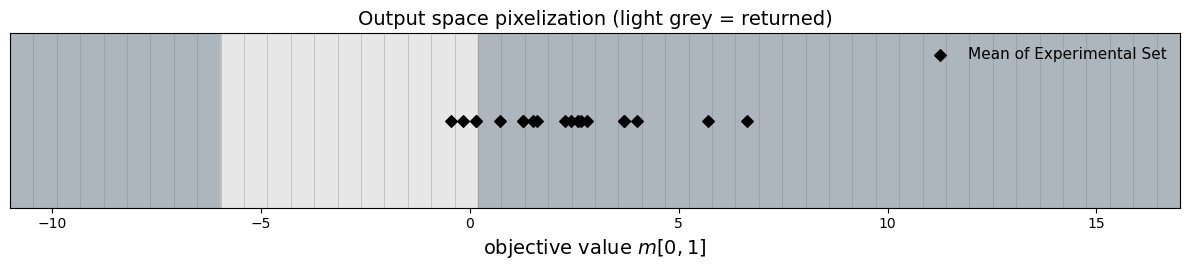

In [31]:
def plot_output_bins(title, interval=None):
    # 1-D strip over the objective axis: light grey = returned bin, medium grey = screened-out.
    # If `interval=(lo, hi)` is given, overlay it in red to compare with the returned bins.
    plt.figure(figsize=(12, 2.8))
    for i in range(n_bins):
        plt.axvspan(edges_obj[i], edges_obj[i + 1],
                    color=('#e7e7e7' if feas_bin[i] else '#adb5bd'))
    for edge in edges_obj:                       # draw bin boundaries
        plt.axvline(edge, color='grey', lw=0.5, alpha=0.5)
    plt.scatter(sample_mean, np.full_like(sample_mean, 0.5),
                color='black', marker='D', s=35, zorder=5, label='Mean of Experimental Set')
    if interval is not None:
        lo, hi = interval
        plt.axvspan(lo, hi, color='red', alpha=0.15, zorder=4)
        plt.axvline(lo, color='red', lw=2, zorder=6)
        plt.axvline(hi, color='red', lw=2, zorder=6, label=r'plausible bounds')
    plt.yticks([])
    plt.ylim(0, 1)
    plt.xlim(obj_axis_lo, obj_axis_hi)
    plt.xlabel(r'objective value $m[0,1]$', fontsize=14)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=11, frameon=False, loc='upper right')
    plt.tight_layout()
    plt.show()


plot_output_bins('Output space pixelization (light grey = returned)')

## 7. Objective-space pixelization via the plausible bounds

The sweep in Section 6 tests many objective intervals one by one. For a single objective there
is a shortcut that recovers the same range (in fact a tighter one) in just two solves: keep the
same model, but **set the optimization objective to $\mathsf{m}_{01}$** (the decision variable
representing the candidate solution's objective value) and minimize / maximize it —
exactly the optimization that defines the lower and upper *plausible bounds*:

- maximize $\mathsf{m}_{01}$ → the **upper plausible bound** (largest attainable objective value),
- minimize $\mathsf{m}_{01}$ → the **lower plausible bound** (smallest attainable objective value).

Under the convex constraints, here the feasible projection onto the objective axis is an
interval, so $[\,\mathrm{lower},\ \mathrm{upper}\,]$ coincides with the union of the *returned*
bins from Section 6. We reuse the same model and just replace its (constant) objective with
`model.m[0, 1]`.

Two remarks. First, the pixelization in Section 6 returns a bin whenever it contains *at least
one* plausible point, so its returned span is an outer approximation and can be wider than
`[lower, upper]` by up to one bin width. Second, "plausible bounds" is **not** a pre-defined
inference type in the package: we obtain it by reusing the `output_pixelization` model and
swapping in `model.m[0, 1]` as the objective — illustrating how the framework's building blocks
can be recombined to implement inference tasks that ship no dedicated routine.

In [32]:
# Same output-space model; open its pixel so m[0,1] is unconstrained, then swap the
# objective to m[0,1] and solve twice: minimize -> lower plausible bound, maximize -> upper.
M_bound = model_construction(
    exp_set,
    num_of_objectives,
    'output_pixelization',
    functional_properties_list,
    acceptability=acceptability,
    acceptability_parameters=acceptability_parameters,
    discrepancy_type=discrepancy_type,
    functional_properties_parameters=functional_properties_parameters,
    x0_feasible_region_A_ineq=A_box,
    x0_feasible_region_b_ineq=b_box,
    **confidence_kwargs,
)
# Open the output pixel by deactivating its two bound constraints (cleaner than a big-M box).
M_bound.C_m0_pixel_lb.deactivate()
M_bound.C_m0_pixel_ub.deactivate()


def solve_bound(model, sense):
    """Set OBJ = m[0,1] with the given sense, solve, return the optimal objective value."""
    model.del_component(model.OBJ)
    model.OBJ = pyo.Objective(expr=model.m[0, 1], sense=sense)
    res = solver.solve(model, tee=False, load_solutions=True)
    tc = res.solver.termination_condition
    assert tc == pyo.TerminationCondition.optimal, f"bound solve not optimal: {tc}"
    return float(pyo.value(model.m[0, 1]))


m0_min = solve_bound(M_bound, pyo.minimize)
m0_max = solve_bound(M_bound, pyo.maximize)

# Compare with the returned bins from Section 6.
returned_lo = float(edges_obj[:-1][feas_bin].min())
returned_hi = float(edges_obj[1:][feas_bin].max())
bin_width   = float(edges_obj[1] - edges_obj[0])

print(f"lower / upper plausible bound : [{m0_min:.4f}, {m0_max:.4f}]")
print(f"returned-bin span   : [{returned_lo:.4f}, {returned_hi:.4f}]")
print(f"(agree up to the bin width {bin_width:.3f})")

lower / upper plausible bound : [-5.8328, -0.0670]
returned-bin span   : [-5.9600, 0.2000]
(agree up to the bin width 0.560)


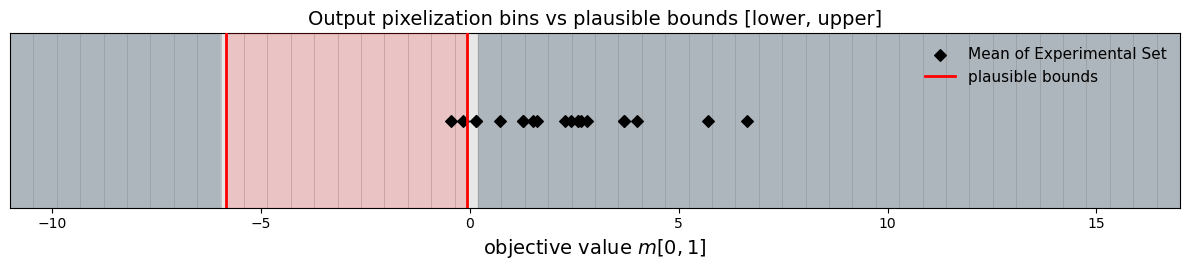

In [33]:
plot_output_bins('Output pixelization bins vs plausible bounds [lower, upper]', interval=(m0_min, m0_max))

In [34]:
import numpy as np
from src.plausible_inference.model_construction import model_construction
from src.plausible_inference.utils.solver_config import get_plausibility_solver
from src.plausible_inference.execution_engine import ExecutionConfig, run_execution_engine

# Two simulated solutions in 2-D, single objective, with explicit confidence bounds.
exp_set = np.array([[0.0, 0.0], [1.0, 1.0]])
lower   = np.array([[1.0], [2.0]])
upper   = np.array([[2.0], [3.0]])

# Build a screening model: is x0 a near-optimal (within 0.5) point for some convex
# objective consistent with the data?
model = model_construction(
    exp_set,
    num_objectives=1,
    inference_type="screening",
    functional_properties_list=[["convexity"]],
    acceptability="delta-optimality",
    acceptability_parameters={"delta": 0.5},
    discrepancy_type="confidence_region",
    upper_confidence_bounds=upper,
    lower_confidence_bounds=lower,
    feasibility_check_solver=None,   # skip the structural feasibility pre-check
)

solver = get_plausibility_solver("gurobi")
candidates = np.array([[5.0, 5.0]])           # one candidate x0, shape (n, s)
results = run_execution_engine(
    ExecutionConfig(inference_type="screening"), model, solver, candidates
)
print(results)   # DataFrame: idx, solve_status='completed', result='returned'/'screened_out'

   idx solve_status    result
0    0    completed  returned
